In [4]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

RuntimeError: CPU dispatcher tracer already initlized

In [ ]:
CSV_PATH = "archive/data.csv"
IMAGE_DIR = "archive/image"

df = pd.read_csv(CSV_PATH)
image_column = df.columns[0]
df["image_path"] = df[image_column].astype(str).apply(
    lambda x: os.path.join(IMAGE_DIR, x + ".jpeg")
)
df = df[df["image_path"].apply(os.path.exists)]
print("Total valid samples:", len(df))

Total valid samples: 1512


In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["label_encoded"] = encoder.fit_transform(df["classes"])
print("Classes:", encoder.classes_)

Classes: ['bumper_dent' 'bumper_scratch' 'door_dent' 'door_scratch' 'glass_shatter'
 'head_lamp' 'tail_lamp' 'unknown']


In [ ]:
IMG_SIZE = 224
images, labels = [], []

for _, row in df.iterrows():
    img = cv2.imread(row["image_path"])
    if img is None:
        continue
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype("float32") / 255.0
    images.append(img)
    labels.append(row["classes"])

X = np.array(images)
y = np.array(labels)

encoder = LabelEncoder()
y = encoder.fit_transform(y)

num_classes = len(np.unique(y))

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(X_train)

In [ ]:
def build_cnn12(params, num_classes):
    inp = Input(shape=(224,224,3))

    x = Conv2D(32,(3,3),padding='same',activation='relu')(inp)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)

    x = Conv2D(64,(3,3),activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)

    x = Conv2D(128,(3,3),activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)

    x = Conv2D(256,(3,3),activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)

    x = Conv2D(512,(3,3),activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)

    x = GlobalAveragePooling2D()(x)

    x = Dense(params['dense1'], activation='relu')(x)
    x = Dropout(0.3)(x, training=True)   # FIXED

    x = Dense(params['dense2'], activation='relu')(x)
    x = Dropout(0.3)(x, training=True)

    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=params['lr']),
        loss='categorical_crossentropy',   # FIXED
        metrics=['accuracy']
    )

    return model

In [ ]:
class EHOA:
    def __init__(self, pop=3, iters=2):
        self.pop = pop
        self.iters = iters

    def random_params(self):
        return {
            "lr": 10**np.random.uniform(-4,-3),
            "dense1": np.random.choice([256,512]),
            "dense2": np.random.choice([128,256])
        }

    def fitness(self, params):
        model = build_cnn12(params, num_classes)

        history = model.fit(
            datagen.flow(X_train[:300], y_train_cat[:300], batch_size=32),
            validation_data=(X_val, y_val_cat),
            epochs=2,
            verbose=0
        )

        return max(history.history['val_accuracy'])

    def optimize(self):
        best_score = 0
        best_params = None

        for i in range(self.iters):
            print(f"\nIteration {i+1}")

            for j in range(self.pop):
                params = self.random_params()
                score = self.fitness(params)

                print(f"Candidate {j+1} → {score:.4f}")

                if score > best_score:
                    best_score = score
                    best_params = params

        return best_params

In [ ]:
ehoa = EHOA(pop=3, iters=2)
best_params = ehoa.optimize()

print("Best Params:", best_params)


Iteration 1


c:\Users\Bhanu Praneeth G\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Candidate 1 → 0.1523
Candidate 2 → 0.1258
Candidate 3 → 0.1258

Iteration 2
Candidate 1 → 0.1325
Candidate 2 → 0.1258
Candidate 3 → 0.1258
Best Params: {'lr': 0.0005355165547723443, 'dense1': np.int64(256), 'dense2': np.int64(128)}


In [ ]:
model = build_cnn12(best_params, num_classes)

early = EarlyStopping(patience=6, restore_best_weights=True)
reduce = ReduceLROnPlateau(patience=3)

history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_val, y_val_cat),
    epochs=40,
    callbacks=[early, reduce],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.2126 - loss: 2.2168 - val_accuracy: 0.1192 - val_loss: 2.4184 - learning_rate: 5.3552e-04
Epoch 2/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.3191 - loss: 1.8899 - val_accuracy: 0.1258 - val_loss: 3.3117 - learning_rate: 5.3552e-04
Epoch 3/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.3102 - loss: 1.7334 - val_accuracy: 0.0993 - val_loss: 3.7917 - learning_rate: 5.3552e-04
Epoch 4/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.3552 - loss: 1.6596 - val_accuracy: 0.1060 - val_loss: 3.3154 - learning_rate: 5.3552e-04
Epoch 5/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.3862 - loss: 1.6249 - val_accuracy: 0.0861 - val_loss: 3.2690 - learning_rate: 5.3552e-05
Epoch 6/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.4103 - loss: 1.5223 - val_accuracy: 0.0927 - val_loss: 3.3734 - learning_rate: 5.3552e-05
Epoch 7/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.4396 - loss:

In [ ]:
def mc_dropout_predict(model, X, T=30):
    preds = []
    for _ in range(T):
        preds.append(model(X, training=True).numpy())
    preds = np.array(preds)
    return preds.mean(axis=0), preds.std(axis=0)

In [ ]:
mean_pred, uncertainty = mc_dropout_predict(model, X_test)

pred_classes = np.argmax(mean_pred, axis=1)
confidence = np.max(mean_pred, axis=1)
uncertainty_score = np.mean(uncertainty, axis=1)

fraud_flags = []

for i in range(len(X_test)):
    if confidence[i] < 0.6 and uncertainty_score[i] > 0.2:
        fraud_flags.append("HIGH RISK ⚠️")
    elif confidence[i] < 0.75:
        fraud_flags.append("MEDIUM RISK ⚠️")
    else:
        fraud_flags.append("SAFE ✅")

In [ ]:
y_true = encoder.inverse_transform(y_test)
y_pred = encoder.inverse_transform(pred_classes)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
print("F1:", f1_score(y_true, y_pred, average='weighted'))

print("\nClassification Report")
print(classification_report(y_true, y_pred))

Accuracy: 0.4605263157894737
Precision: 0.504540862530821
Recall: 0.4605263157894737
F1: 0.46165360907208736

Classification Report
                precision    recall  f1-score   support

   bumper_dent       0.42      0.62      0.50        13
bumper_scratch       0.12      0.12      0.12         8
     door_dent       0.62      0.40      0.48        20
  door_scratch       0.71      0.31      0.43        16
 glass_shatter       0.32      0.46      0.38        13
     head_lamp       0.38      0.23      0.29        13
     tail_lamp       0.32      0.64      0.43        14
       unknown       0.60      0.55      0.57        55

      accuracy                           0.46       152
     macro avg       0.44      0.42      0.40       152
  weighted avg       0.50      0.46      0.46       152



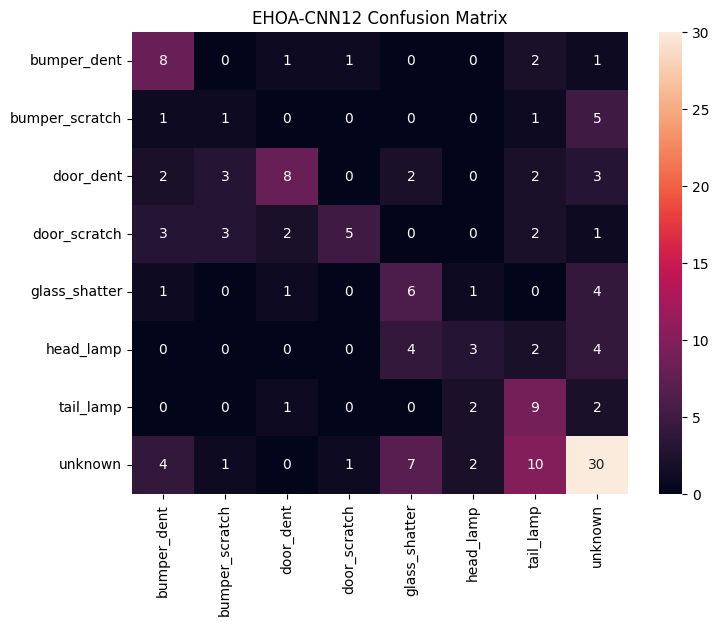

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)

plt.title("EHOA-CNN12 Confusion Matrix")
plt.show() 